# Progetto del corso - Introduzione al Pensiero Computazionale e alla Data Science

**Dataset scelto:** Employee Attrition
**Obiettivo:** previsione dell'abbandono dei dipendenti (`Attrition`)

**Team:** [Paolo Magnanelli - 1231652], [Asia Milan - 1217247].

---
# Fase 1 - Setup del progetto

In questa cella importiamo le librerie che useremo in tutto il notebook.

- `pandas`, `numpy` per la gestione dei dati
- `matplotlib`, `seaborn` per le visualizzazioni
- `scikit-learn` per modellazione e metriche

In [192]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)
from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

In [193]:
df = pd.read_csv("Employee_Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---
# Fase 2 - Descrizione e comprensione del dataset

Lo schema che useremo per ogni domanda è:

1. esposizione della domanda/ipotesi;
2. recupero e visualizzazione dell'informazione;
3. risposta/considerazione.

**Iniziamo con una panoramica**: dimensioni, tipi di variabili e presenza di
valori mancanti.

In [194]:
print("Numero di righe:", df.shape[0])
print("Numero di colonne:", df.shape[1])
df.info()

Numero di righe: 1470
Numero di colonne: 35
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non

In [195]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Considerazioni:** il dataset contiene 1470 osservazioni (dipendenti) e 35
colonne. Non sono presenti tipi di dato anomali a prima vista: la maggior parte
delle variabili è numerica (int64), mentre alcune sono categoriche (stringhe).
Procediamo a verificare i valori mancanti.

### Domanda 1 - Ci sono valori mancanti?

In [196]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


**Considerazioni:** non risultano valori mancanti (`NaN`) in nessuna colonna.


### Domanda 2 - Quali sono le variabili numeriche e quali categoriche?


In [197]:
print("Variabili nuemriche e catgoriche:")
df.dtypes.value_counts()

Variabili nuemriche e catgoriche:


,count
int64,26
object,9


In [198]:
numeriche = df.select_dtypes(include="number").columns
categoriche = df.select_dtypes(exclude="number").columns

print("Variabili numeriche:")
for col in numeriche:
    print("-", col)

print("\nVariabili categoriche:")
for col in categoriche:
    print("-", col)

Variabili numeriche:
- Age
- DailyRate
- DistanceFromHome
- Education
- EmployeeCount
- EmployeeNumber
- EnvironmentSatisfaction
- HourlyRate
- JobInvolvement
- JobLevel
- JobSatisfaction
- MonthlyIncome
- MonthlyRate
- NumCompaniesWorked
- PercentSalaryHike
- PerformanceRating
- RelationshipSatisfaction
- StandardHours
- StockOptionLevel
- TotalWorkingYears
- TrainingTimesLastYear
- WorkLifeBalance
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager

Variabili categoriche:
- Attrition
- BusinessTravel
- Department
- EducationField
- Gender
- JobRole
- MaritalStatus
- Over18
- OverTime


**Considerazioni:** ci sono 26 variabili numeriche e 9 categoriche
(incluso il target `Attrition`). Tra le variabili categoriche troviamo
informazioni come `Department`, `JobRole`, `MaritalStatus`, `OverTime`, ecc.

### Domanda 3 - Esistono colonne che, anche se numeriche, contengono un solo valore?

Una colonna che ha sempre lo stesso valore non porta nessuna informazione utile
per un modello predittivo: è quindi importante identificarla.

In [199]:
nunique = df.nunique().sort_values()
nunique.head(10)

,0
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [200]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print("Variabili costanti:", constant_cols)

Variabili costanti: ['EmployeeCount', 'Over18', 'StandardHours']


**Considerzioni**: Emerge che alcune variabili presentano un solo valore (come `EmployeeCount`, `Over18` e `StandardHours`) e quindi non forniscono informazioni utili per l’analisi.

Altre variabili hanno solo poche categorie (ad esempio `Attrition`, `OverTime`, `Gender`), sono quindi facilmente interpretabili ma con una variabilità bassa.

Infine, alcune variabili categoriali presentano più livelli (come `BusinessTravel`, `Department` e `MaritalStatus`), mostrano diversità e potenziale informativo.


### Domanda 4 -  Qual è la distribuzione della variabile target `Attrition`? Il dataset è bilanciato o sbilanciato?


In [201]:
attrition_counts = df["Attrition"].value_counts()
attrition_per = df["Attrition"].value_counts(normalize=True) * 100

print(attrition_counts)
print()
print(attrition_per.round(2)) #solo due decimali

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.88
Yes    16.12
Name: proportion, dtype: float64


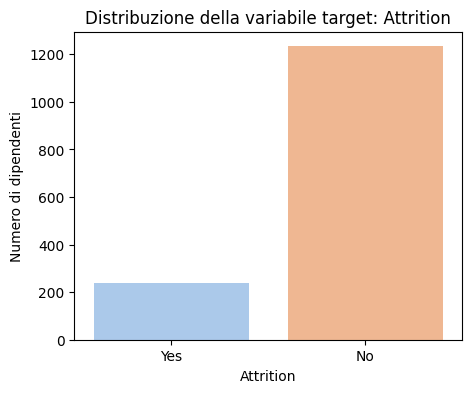

In [202]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df,
              x="Attrition",
              hue="Attrition",
              palette="pastel",
)
plt.xlabel("Attrition")
plt.ylabel("Numero di dipendenti")

plt.title("Distribuzione della variabile target: Attrition")
plt.show()

**Considerazioni:** la classe `Yes` (dipendenti che hanno lasciato
l'azienda) rappresenta circa il 16% del dataset, contro l'84% della classe
`No`. Si tratta quindi di un dataset **sbilanciato (class imbalance)**: questo
sarà importante in fase 4/5, perché un modello che predice sempre `No`
otterrebbe un'accuracy "ingannevole" di circa l'84% senza essere effettivamente
utile.

### Domanda 5 - Quali sono le statistiche descrittive principali delle variabili numeriche più rilevanti?


In [203]:
df[["Age", "MonthlyIncome", "DistanceFromHome", "TotalWorkingYears",
    "YearsAtCompany", "JobSatisfaction"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0
JobSatisfaction,1470.0,2.728571,1.102846,1.0,2.0,3.0,4.0,4.0


**Considerazioni:** l'età media dei dipendenti è di circa 37 anni (min 18,
max 60). Il reddito mensile (`MonthlyIncome`) è molto variabile (da circa 1000 a
quasi 20000), con una deviazione standard ampia che evidenzia la presenza di
ruoli/livelli molto diversi tra loro.

`YearsAtCompany` ha una mediana inferiore
alla media. Questo indica una distribuzione asimmetrica e con outliers che influenzano la media, ovvero alcuni dipendenti di
lunga data.

### Domanda 6 - Sono presenti outlier evidenti nelle variabili numeriche rilevanti?


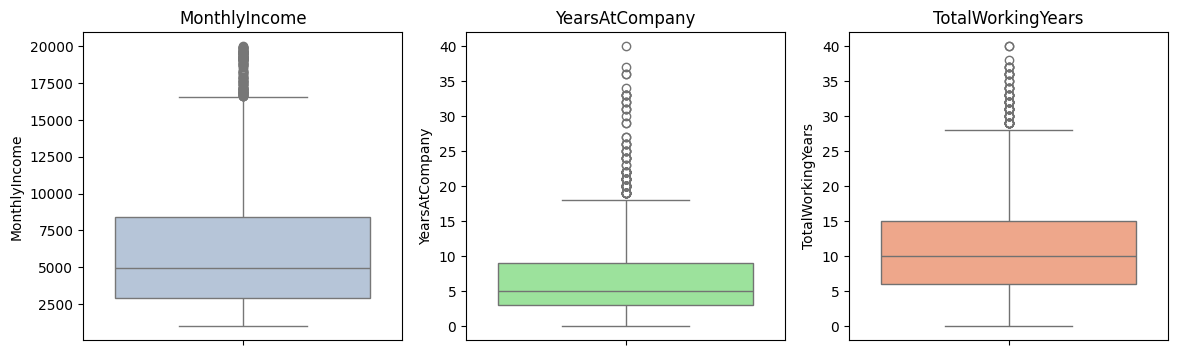

In [204]:
# crea una figura con 1 riga e 3 grafici (colonne)
# figsize controlla la dimensione del grafico (larghezza 14, altezza 4)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.boxplot(data=df, y="MonthlyIncome", ax=axes[0], color="lightsteelblue")
# ax=axes[0] -> primo spazio del grafico (a sinistra)
axes[0].set_title("MonthlyIncome")

sns.boxplot(data=df, y="YearsAtCompany", ax=axes[1], color="lightgreen")
axes[1].set_title("YearsAtCompany")

sns.boxplot(data=df, y="TotalWorkingYears", ax=axes[2], color="lightsalmon")
axes[2].set_title("TotalWorkingYears")

plt.show()

**Considerazioni**: usiamo dei boxplot per individuare visivamente valori estremi.

Tutte e tre le variabili mostrano alcuni outliers. Tuttavia questi valori (es. dipendenti con molti anni di servizio o stipendi alti) rappresentano situazioni realistiche e non errori di inserimento dati. Si tratta probabilmente di dipendenti senior/dirigenziali. **Ne teniamo conto nell'interpretazione dei risultati**.

### Domanda 7 - Quali sono le categorie più frequenti nelle variabili categoriche principali?


In [205]:
for col in ["Department", "JobRole", "MaritalStatus", "BusinessTravel", "OverTime"]:
    print(f"--- {col} ---")
    print(df[col].value_counts(normalize=True).round(4) * 100)
    print()

--- Department ---
Department
Research & Development    65.37
Sales                     30.34
Human Resources            4.29
Name: proportion, dtype: float64

--- JobRole ---
JobRole
Sales Executive              22.18
Research Scientist           19.86
Laboratory Technician        17.62
Manufacturing Director        9.86
Healthcare Representative     8.91
Manager                       6.94
Sales Representative          5.65
Research Director             5.44
Human Resources               3.54
Name: proportion, dtype: float64

--- MaritalStatus ---
MaritalStatus
Married     45.78
Single      31.97
Divorced    22.24
Name: proportion, dtype: float64

--- BusinessTravel ---
BusinessTravel
Travel_Rarely        70.95
Travel_Frequently    18.84
Non-Travel           10.20
Name: proportion, dtype: float64

--- OverTime ---
OverTime
No     71.7
Yes    28.3
Name: proportion, dtype: float64



**Considerazioni**: la maggior parte dei dipendenti:
* lavora nel dipartimento "Research & Development" (circa 65%),
* è sposata (circa 46%),
* viaggia raramente per lavoro ("Travel_Rarely", circa 71%).

Circa il 28% dei dipendenti fa straordinari (`OverTime` = Yes). **Questa variabile sarà particolarmente interessante da analizzare in fase 3, perché spesso è associata all'`attrition`**.

# Domande 8 - Alcune features numeriche sono fortemente correlate tra loro?

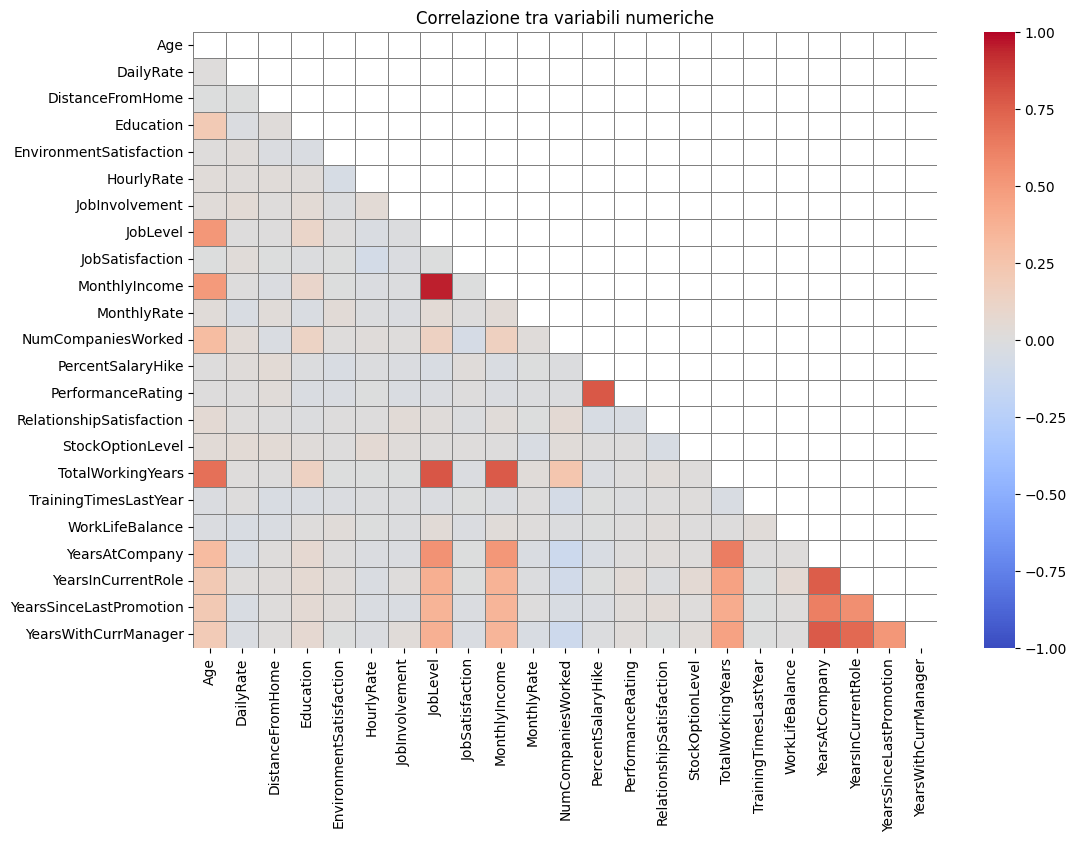

In [206]:
variabili = [col for col in df.select_dtypes(include="number")
             if col not in constant_cols + ["EmployeeNumber"]]

corr = df[variabili].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask= mask,
    cmap= "coolwarm",
    vmin= -1,
    vmax= 1,
    center= 0,
    linewidths= 0.7,        #linee più spesse
    linecolor= "gray"      #colore delle linee
)

plt.title("Correlazione tra variabili numeriche")
plt.show()


In [207]:
lista= []


for col1 in corr.columns:
    for col2 in corr.columns:
        if col1 < col2:
            valore= corr.loc[col1, col2]
            lista.append([col1, col2, abs(valore)])


tabella= pd.DataFrame(lista, columns=["Variabile 1", "Variabile 2", "Correlazione"])
tabella= tabella.sort_values(by="Correlazione", ascending=False)

top10= tabella.head(10)
print(top10)

            Variabile 1              Variabile 2  Correlazione
134            JobLevel            MonthlyIncome      0.950300
141            JobLevel        TotalWorkingYears      0.782208
198   PercentSalaryHike        PerformanceRating      0.773550
168       MonthlyIncome        TotalWorkingYears      0.772893
249      YearsAtCompany     YearsWithCurrManager      0.769212
247      YearsAtCompany       YearsInCurrentRole      0.758754
251  YearsInCurrentRole     YearsWithCurrManager      0.714365
15                  Age        TotalWorkingYears      0.680381
234   TotalWorkingYears           YearsAtCompany      0.628133
248      YearsAtCompany  YearsSinceLastPromotion      0.618409


**Considerazioni**: alcune variabili numeriche sono fortemente correlate tra loro, in particolare c'è una correlazione molto elevata tra `MonthlyIncome` e `JobLevel` (circa 0.95), mostrando, come si poteva immagianre, che stipendi più alti sono correlati a lavori più elevati.

Anche `TotalWorkingYears` è fortemente correlata con `JobLevel` e `MonthlyIncome` (circa 0.78), eveidenziando che l'esperienza lavorativa totale influisce sia sul ruolo che sul reddito.

Le variabili legate alla permanenza (`YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) mostrano anch’esse correlazioni elevate tra loro (tra 0.71 e 0.77), indicando una forte relazione tra anzianità e stabilità lavorativa.

Un'ulteriore correlazione significativa è tra `PercentSalaryHike` e `PerformanceRating` (circa 0.77), quindi le performance lavorative influenzano gli aumenti salariali.

Infine, `Age` è moderatamente correlata con `TotalWorkingYears`(circa 0.68), coerentemente collegato al fatto che i lavoratori più anziani tendono ad avere una maggiore esperienza.


### Conclusioni della fase 2
1. Il dataset contiene 1470 osservazioni e 35 variabili:
  - 26 numeriche
  - 9 categoriche  

2. Non sono presenti valori mancanti, quindi i dati risultano completi.

3. La variabile target `Attrition` è sbilanciata come ci aspettavamo da un dataset HR che tratta di tale tema:
  - circa 84% dipendenti che restano  
  - circa 16% che lasciano  

4. Sono presenti alcune variabili non informative (costanti), come:
  - `EmployeeCount`
  - `Over18`
  - `StandardHours`

5. Le variabili numeriche mostrano:
  - elevata variabilità → `MonthlyIncome`
  - presenza di outlier, ma realistici → dipendenti senior

6. Le variabili categoriche evidenziano che:
  - la maggior parte lavora in "Research & Development"
  - molti sono sposati
  - circa il 28% fa straordinari  

7. L’analisi delle correlazioni mostra:
  - forte relazione tra reddito e livello del ruolo
  - legame tra esperienza, reddito e posizione lavorativa
  - alta correlazione tra variabili legate agli anni in azienda  



---
# Fase 3 - Analisi esplorativa e visualizzazione

**Obiettivo:** capire (e comunicare) le relazioni tra le feature, in particolare
rispetto al target `Attrition`.

Per facilitare i confronti, creiamo una versione numerica del target
(`Attrition_num`): `1` = "Yes" (il dipendente ha lasciato l'azienda), `0` = "No".

In [208]:
df["Attrition_num"] = (df["Attrition"] == "Yes").astype(int)
df[["Attrition", "Attrition_num"]].head()

,Attrition,Attrition_num
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


### Domanda 1 - I dipendenti che fanno straordinari (`OverTime`) lasciano l'azienda più frequentemente?

In [209]:
overtime_attrition = pd.crosstab(df["OverTime"], df["Attrition"], normalize="index").round(4) * 100
overtime_attrition

Attrition,No,Yes
OverTime,,
No,89.56,10.44
Yes,69.47,30.53


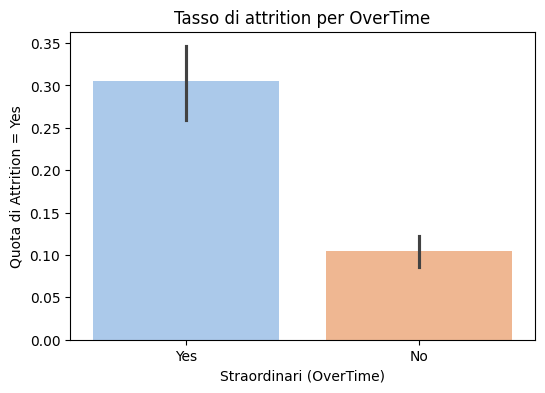

In [210]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="OverTime", y="Attrition_num", hue="OverTime",
            palette="pastel", legend=False)
plt.title("Tasso di attrition per OverTime")
plt.xlabel("Straordinari (OverTime)")
plt.ylabel("Quota di Attrition = Yes")
plt.show()

**Considerazioni:** chi fa straordinari ha un tasso di attrition di circa
il 31%, contro circa il 10% di chi non ne fa. `OverTime` sembra quindi una
variabile fortemente associata all'abbandono dell'azienda.

### Domanda 2 - Il reddito mensile (`MonthlyIncome`) è diverso tra dipendenti che restano e dipendenti che lasciano l'azienda?

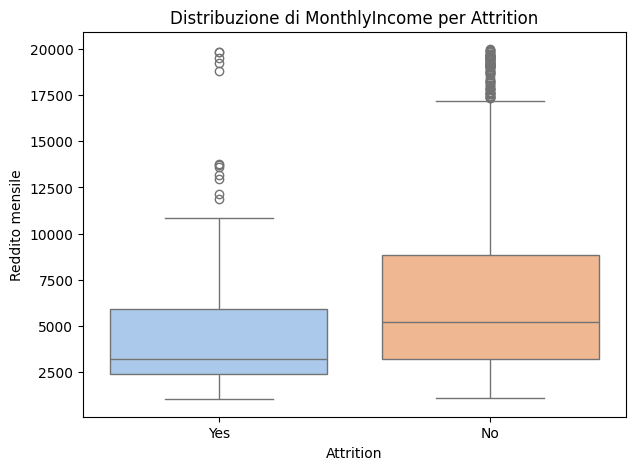

In [211]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome", hue="Attrition",
            palette="pastel", legend=False)
plt.title("Distribuzione di MonthlyIncome per Attrition")
plt.xlabel("Attrition")
plt.ylabel("Reddito mensile")
plt.show()

In [212]:
df.groupby("Attrition")["MonthlyIncome"].describe()[["mean", "50%", "std"]]

,mean,50%,std
Attrition,,,
No,6832.739659,5204.0,4818.208001
Yes,4787.092827,3202.0,3640.210367


**Considerazioni:** i dipendenti che lasciano l'azienda (`Yes`) hanno un
reddito mensile mediano sensibilmente più basso rispetto a chi resta. La
distribuzione è inoltre più concentrata sui valori bassi (vedi boxplot). Questo
suggerisce che un reddito basso possa essere un fattore associato
all'attrition.

### Domanda 3 - Il reddito mensile varia tra i diversi ruoli (`JobRole`), e come si posiziona l'attrition all'interno di ciascun ruolo?

Finora abbiamo confrontato `MonthlyIncome` solo rispetto ad `Attrition` (Domanda
2). Qui scomponiamo ulteriormente il confronto per `JobRole`, usando un
**catplot** con `kind="box"` per vedere la distribuzione in ciascun gruppo, e
sovrapponiamo i singoli punti con uno **swarmplot** per non perdere informazioni
sulle singole osservazioni (utile perché alcuni ruoli hanno pochi dipendenti).

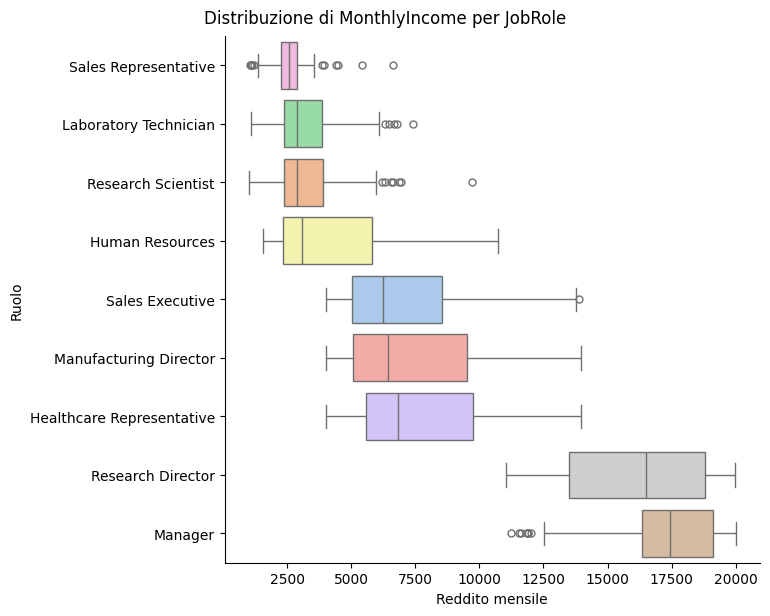

In [213]:
order_roles = (
    df.groupby("JobRole")["MonthlyIncome"].median().sort_values().index
)

g = sns.catplot(
    data=df,
    x="MonthlyIncome",
    y="JobRole",
    order=order_roles,
    kind="box",
    height=6,
    aspect=1.3,
    palette="pastel",
    hue="JobRole",
    legend=False,
)
g.set_axis_labels("Reddito mensile", "Ruolo")
g.fig.suptitle("Distribuzione di MonthlyIncome per JobRole", y=1.02)
plt.show()

**Considerazioni:** il reddito mensile varia enormemente in base al ruolo: i
`Manager` e i `Research Director` guadagnano molto più dei `Sales
Representative` o dei `Laboratory Technician`, riflettendo livelli di
inquadramento diversi (coerente con la forte correlazione `JobLevel`-
`MonthlyIncome` osservata in Fase 2).

### Domanda 4 - Il `work-life balance` influisce sull'`attrition`?


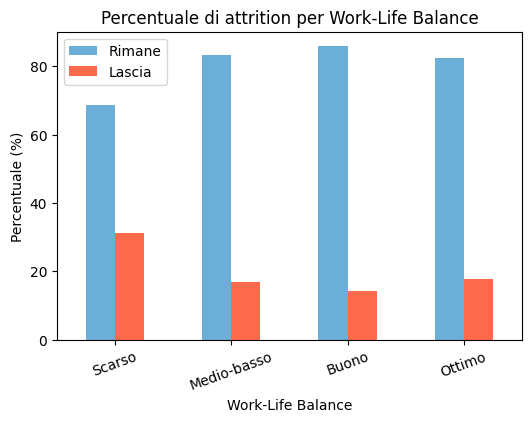

In [214]:
tab = pd.crosstab(
    df["WorkLifeBalance"],
    df["Attrition"],
    normalize= "index"
) * 100

tab.index = ["Scarso", "Medio-basso", "Buono", "Ottimo"]
tab.plot(kind= "bar", figsize=(6,4), color=["#6baed6", "#fb6a4a"])

plt.legend(["Rimane", "Lascia"])
plt.xlabel("Work-Life Balance")
plt.ylabel("Percentuale (%)")
plt.xticks(rotation= 20)

plt.title("Percentuale di attrition per Work-Life Balance")
plt.show()

**Considerazioni**: la percentuale di attrition è più alta nei dipendenti con un work-life balance scarso e diminuisce progressivamente al migliorare dell’equilibrio vita-lavoro. Tuttavia, il livello “ottimo” non mostra un ulteriore calo significativo rispetto a “buono”, suggerendo una possibile stabilizzazione dell’effetto.

### Domanda 5 - I dipendenti più “a rischio” di attrition si concentrano in specifiche combinazioni di età e esperienza?


In [215]:
df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=[18, 25, 35, 45, 60],
    labels=[
        "Giovani (18-25)",
        "Giovani adulti (26-35)",
        "Adulti (36-45)",
        "Senior (46-60)"
    ]
)

In [216]:
df["Experience"] = pd.cut(
    df["YearsAtCompany"],
    bins=[0, 3, 10, 40],
    labels=["Nuovi", "Intermedi", "Esperti"]
)

In [217]:
tab = pd.crosstab(
    [df["AgeGroup"], df["Experience"]],
    df["Attrition"],
    normalize="index"
) * 100

tab.round(2)

Attrition                             No    Yes
AgeGroup               Experience              
Giovani (18-25)        Nuovi       58.33  41.67
                       Intermedi   85.71  14.29
Giovani adulti (26-35) Nuovi       69.59  30.41
                       Intermedi   85.20  14.80
                       Esperti     90.62   9.38
Adulti (36-45)         Nuovi       84.87  15.13
                       Intermedi   92.89   7.11
                       Esperti     92.98   7.02
Senior (46-60)         Nuovi       90.62   9.38
                       Intermedi   84.56  15.44
                       Esperti     91.18   8.82

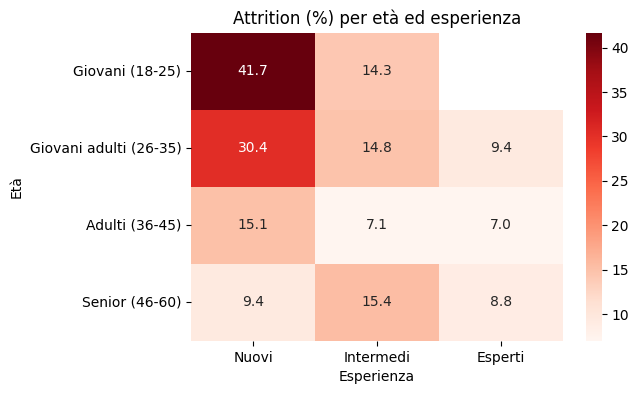

In [218]:
tab_reset = tab.reset_index()
pivot = tab_reset.pivot(
    index= "AgeGroup",
    columns= "Experience",
    values= "Yes"
)

plt.figure(figsize=(6,4))
sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".1f")

plt.xlabel("Esperienza")
plt.ylabel("Età")

plt.title("Attrition (%) per età ed esperienza")
plt.show()

**Considerazioni**: l’analisi congiunta di età ed esperienza mostra che l’attrition è più elevata tra i dipendenti più giovani e con minore esperienza. Nella fascia 18–25 anni si osserva il valore più alto (41.7%) tra i lavoratori “nuovi”. All’aumentare dell’esperienza, la probabilità di attrition diminuisce in tutte le fasce d’età, indicando una maggiore stabilità dei dipendenti con più anni in azienda.
Inoltre, per le fasce più adulte (36–45 e 46–60), i livelli di attrition sono più bassi e meno variabili tra i gruppi.
**Questo evidenzia che il rischio di abbandono si concentra principalmente nelle fasi iniziali della carriera**

### Domanda 6 - Come si distribuisce l'età dei dipendenti, e c'è una differenza tra chi resta e chi lascia l'azienda?

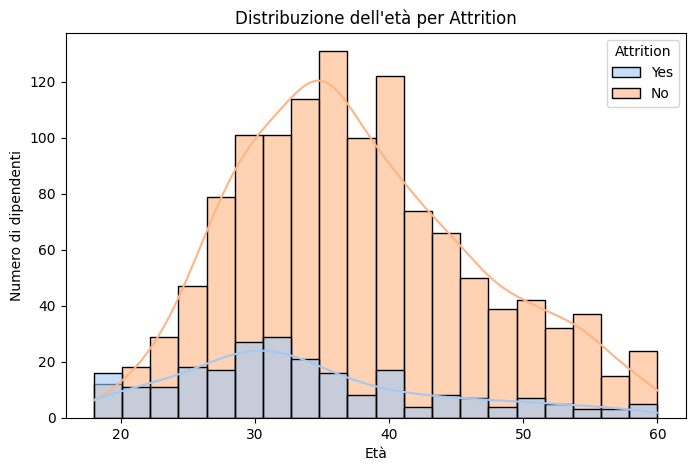

In [219]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Attrition", kde=True, bins=20,
              palette="pastel", multiple="layer", alpha=0.6)
plt.title("Distribuzione dell'età per Attrition")
plt.xlabel("Età")
plt.ylabel("Numero di dipendenti")
plt.show()

**Considerazioni:** la distribuzione dei dipendenti che lasciano l'azienda
è spostata verso età più giovani rispetto a chi resta. Questo è coerente con
l'idea che i dipendenti più giovani, magari ancora all'inizio della carriera,
possano essere più propensi a cambiare lavoro.

### Domanda 7 - Chi ha cambiato più aziende ha più probabilità di lasciare?


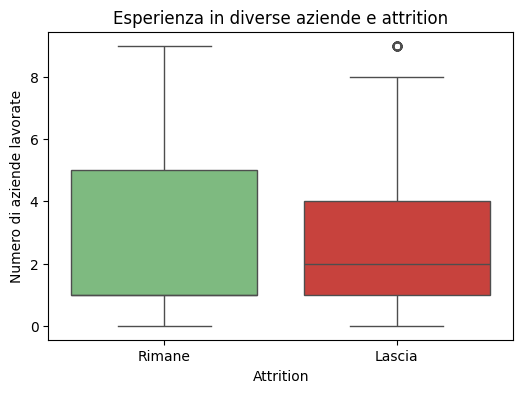

In [220]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Attrition",
    y="NumCompaniesWorked",
    hue="Attrition",
    data=df,
    palette=["#74c476", "#de2d26"]
)

# Cambiamo le etichette per chiarezza
plt.xticks(ticks=[0,1], labels=["Rimane", "Lascia"])

plt.xlabel("Attrition")
plt.ylabel("Numero di aziende lavorate")

plt.title("Esperienza in diverse aziende e attrition")
plt.show()

**Considerazioni**: la sovrapposizione delle distribuzioni indica che la mobilità lavorativa passata non è lagato all’attrition.

### Domanda 8 - Come si distribuisce congiuntamente l'esperienza lavorativa (`TotalWorkingYears`) con il reddito (`MonthlyIncome`), e dove si concentra l'attrition in questo spazio?

`TotalWorkingYears` e `MonthlyIncome` sono la coppia di variabili più
correlata individuata nel clustermap (Domanda 6). Un semplice scatterplot
mostra la relazione punto per punto, ma con 1470 osservazioni diventa
difficile capire **dove si concentra la maggior parte dei dipendenti**.

Per questo sovrapponiamo allo scatterplot una **stima di densità bivariata
(kdeplot 2D)**: le linee di contorno racchiudono le zone più "dense" del
piano, in modo analogo alle curve di livello di una mappa topografica.
Calcoliamo i contorni separatamente per i due gruppi di `Attrition`, così da
confrontare non solo i singoli punti ma anche le zone di massima
concentrazione dei due gruppi.

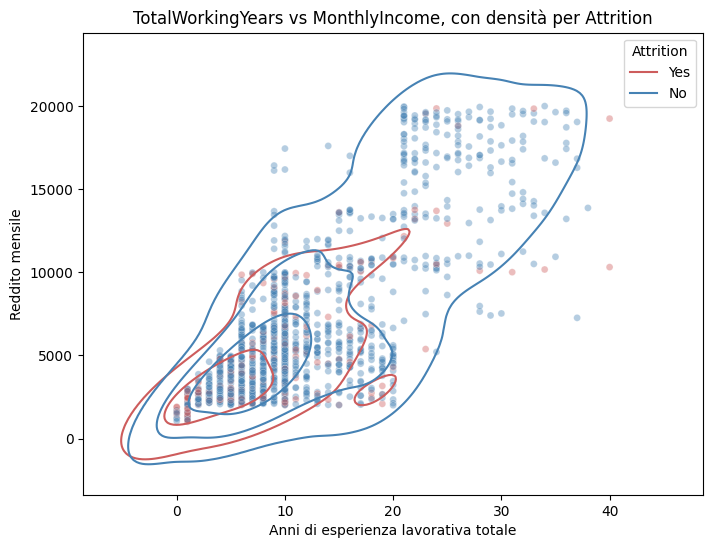

In [221]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="TotalWorkingYears",
    y="MonthlyIncome",
    hue="Attrition",
    palette={"No": "steelblue", "Yes": "indianred"},
    alpha=0.4,
    s=25,
)

sns.kdeplot(
    data=df,
    x="TotalWorkingYears",
    y="MonthlyIncome",
    hue="Attrition",
    palette={"No": "steelblue", "Yes": "indianred"},
    levels=4,
    linewidths=1.5,
)

plt.title("TotalWorkingYears vs MonthlyIncome, con densità per Attrition")
plt.xlabel("Anni di esperienza lavorativa totale")
plt.ylabel("Reddito mensile")
plt.show()

**Considerazioni:** lo scatterplot confema la relazione positiva e non
perfettamente lineare tra le due variabili: il reddito tende a crescere con
l'esperienza, ma con una dispersione crescente (dipendenti con la stessa
esperienza possono avere redditi molto diversi, probabilmente per ruolo o
livello). I contorni di densità mostrano che il gruppo `Attrition = Yes`
(rosso) si concentra in una zona più ristretta, con pochi anni di esperienza
e reddito basso, mentre il gruppo `Attrition = No` (blu) ha una zona di
densità massima più ampia e spostata su valori di esperienza e reddito
intermedi. In altre parole, l'attrition non è distribuita uniformemente nello
spazio esperienza-reddito, ma si addensa proprio nella zona "dipendenti
junior e con reddito più basso".

## Riepilogo Fase 3

- `OverTime` è fortemente associato all'attrition (circa 3 volte più probabile per chi fa straordinari).
- I dipendenti che lasciano l'azienda hanno reddito mensile mediano più basso.
- I dipendenti più giovani sembrano leggermente più propensi a lasciare l'azienda.
- Il reddito varia molto per `JobRole`, e l'attrition sembra concentrarsi tra i dipendenti con reddito più basso *all'interno dello stesso ruolo*.
- Un `work-life balance` scarso è associato a un'attrition più alta, con un effetto che si stabilizza ai livelli "buono" e "ottimo".
- Il rischio di attrition si concentra nelle fasi iniziali della carriera: è più alto tra i dipendenti giovani e con poca esperienza in azienda.
- Il numero di aziende lavorate in precedenza non mostra una relazione evidente con l'attrition.

Queste osservazioni guideranno la scelta delle feature e l'interpretazione dei
modelli nelle fasi successive.


---
# Fase 4 - Modellazione

**Obiettivo:** confrontare almeno 3 modelli diversi per predire `Attrition`,
includendo almeno un modello lineare (regressione logistica) e almeno un
modello non lineare (k-NN e/o Random Forest).

## 4.1 Preparazione del dataset

Prima di addestrare i modelli dobbiamo:

1. rimuovere le colonne non informative individuate in Fase 2;
2. convertire le variabili categoriche in numeriche (con `pd.get_dummies`);
3. separare le feature (`X`) dal target (`y`);
4. effettuare il train/test split.


In [222]:
#Rimuoviamo le colonne non informative e il target in formato testo/duplicato
cols_to_drop = constant_cols + ["EmployeeNumber", "Attrition", "Attrition_num"]

X_raw = df.drop(columns=cols_to_drop)
y = df["Attrition_num"]

print("Colonne rimosse:", cols_to_drop)
print("Numero di feature prima della codifica:", X_raw.shape[1])

Colonne rimosse: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber', 'Attrition', 'Attrition_num']
Numero di feature prima della codifica: 32


In [223]:
#Conversione delle variabili categoriche in numeriche tramite one-hot encoding
X = pd.get_dummies(X_raw, drop_first=True)

print("Numero di feature dopo la codifica:", X.shape[1])
X.head()

Numero di feature dopo la codifica: 49


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,AgeGroup_Giovani adulti (26-35),AgeGroup_Adulti (36-45),AgeGroup_Senior (46-60),Experience_Intermedi,Experience_Esperti
0,41,1102,1,2,2,94,3,2,4,5993,...,True,False,False,True,True,False,True,False,True,False
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,True,False,False,False,False,True,True,False
2,37,1373,2,2,4,92,2,1,3,2090,...,False,False,False,True,True,False,True,False,False,False
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,True,False,True,True,False,False,True,False
4,27,591,2,1,1,40,3,1,2,3468,...,False,False,True,False,False,True,False,False,False,False


**Nota sulla codifica:** usiamo `pd.get_dummies(..., drop_first=True)` per
trasformare ogni variabile categorica in una o più colonne binarie (0/1), senza
introdurre un ordinamento artificiale tra categorie che non ne hanno uno (es.
`Department`, `JobRole`). Per le variabili che erano già numeriche e ordinate
(es. `JobSatisfaction`, `Education`) manteniamo invece la codifica numerica
originale.

In [224]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print()
print("Proporzione Attrition=Yes nel training set:", y_train.mean().round(3))
print("Proporzione Attrition=Yes nel test set:", y_test.mean().round(3))

Training set: (1029, 49)
Test set: (441, 49)

Proporzione Attrition=Yes nel training set: 0.161
Proporzione Attrition=Yes nel test set: 0.161


## 4.2 Standardizzazione

La standardizzazione è importante per il k-NN (che si basa sulla distanza tra
punti) e utile anche per la regressione logistica (per confrontare i
coefficienti). Per la Random Forest non è necessaria, ma non è dannosa: per
semplicità usiamo le stesse versioni standardizzate per tutti i modelli.

Calcoliamo media e deviazione standard **solo sul training set**, e applichiamo
la stessa trasformazione al test set, per evitare data leakage.

In [225]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

#Controlliamo che sia tutto corretto
X_train_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes,AgeGroup_Giovani adulti (26-35),AgeGroup_Adulti (36-45),AgeGroup_Senior (46-60),Experience_Intermedi,Experience_Esperti
853,-1.958919,-0.413973,-0.036578,-0.866067,0.270496,-0.547908,0.37805,-0.998363,-1.538894,-0.867017,...,-0.550029,-0.230704,-0.929586,1.475102,-0.644520,-0.848962,-0.677919,-0.480480,-1.030594,-0.447996
435,-0.430695,1.176070,0.699024,-1.835797,-0.651162,-0.449557,0.37805,0.846010,0.264662,1.532088,...,-0.550029,-0.230704,1.075748,-0.677919,1.551543,1.177910,-0.677919,-0.480480,0.970314,-0.447996
587,1.643324,1.296833,0.208623,1.073395,1.192155,0.829007,0.37805,-0.076177,0.264662,-0.737494,...,-0.550029,-0.230704,1.075748,-0.677919,-0.644520,-0.848962,-0.677919,2.081251,0.970314,-0.447996
1170,-1.085648,-0.549831,-0.894779,0.103664,1.192155,1.074884,0.37805,-0.998363,1.166440,-0.860942,...,-0.550029,-0.230704,-0.929586,1.475102,-0.644520,1.177910,-0.677919,-0.480480,0.970314,-0.447996
159,-0.321536,-1.274408,-0.894779,1.073395,0.270496,0.484778,0.37805,-0.998363,0.264662,-0.936660,...,-0.550029,4.334566,1.075748,-0.677919,-0.644520,1.177910,-0.677919,-0.480480,0.970314,-0.447996


## 4.3 Modello 1 - Regressione logistica (modello lineare)

In [226]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

pred_log = log_model.predict(X_test_scaled)
acc_log = accuracy_score(y_test, pred_log)

print(f"Accuracy regressione logistica: {acc_log:.3f}")

Accuracy regressione logistica: 0.875


In [227]:
# Logistic senza scaling
log_model_raw = LogisticRegression(max_iter=1000, random_state=42)
log_model_raw.fit(X_train, y_train)

pred_raw = log_model_raw.predict(X_test)
acc_raw = accuracy_score(y_test, pred_raw)

print(f"Accuracy senza scaling: {acc_raw:.3f}")
print(f"Accuracy con scaling: {acc_log:.3f}")


Accuracy senza scaling: 0.850
Accuracy con scaling: 0.875


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


**Considerazioni**: il confronto tra il modello con e senza standardizzazione mostra che lo scaling migliora le prestazioni della regressione logistica (accuracy da 0.850 a 0.875).
Inoltre, il modello senza scaling presenta un warning di mancata convergenza, segno di difficoltà nel processo di ottimizzazione.
Questo evidenzia che la standardizzazione delle feature è importante per la regressione logistica, poiché permette una migliore convergenza e risultati più stabili.

## 4.4 Modello 2 - k-Nearest Neighbors (modello non lineare)

Individuiamo il valore `k` con l'accuracy più alta e utilizzamolo per il modello.

In [228]:
k_values = [1, 3, 5, 7, 9, 11, 14, 18, 21, 35, 51]

results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    results.append({"k": k, "accuracy": acc})

knn_results = pd.DataFrame(results)
knn_results

,k,accuracy
0,1,0.793651
1,3,0.836735
2,5,0.845805
3,7,0.845805
4,9,0.841270
5,11,0.841270
6,14,0.839002
7,18,0.841270
8,21,0.839002
9,35,0.845805


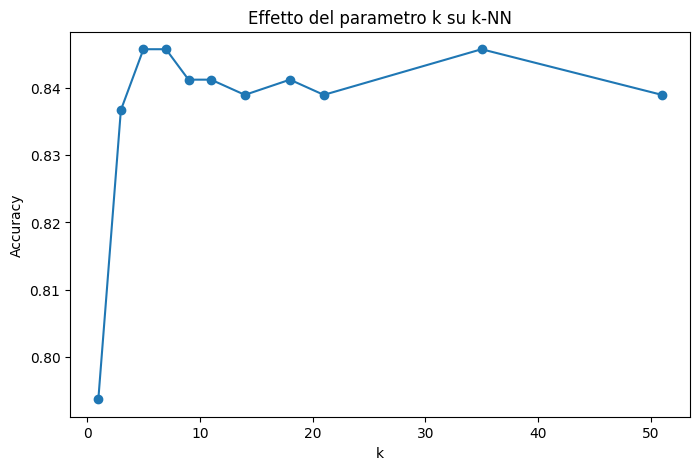

In [229]:
#grafico sui valori k e l'accuracy correlata
plt.figure(figsize=(8,5))
plt.plot(knn_results["k"], knn_results["accuracy"], marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Effetto del parametro k su k-NN")
plt.show()

Individuiamo il valore `k = 14` come il valore con l'accuracy più alta e dissiamo il modello che analizzeremo in seguito.

In [230]:
knn_model = KNeighborsClassifier(n_neighbors=14)
knn_model.fit(X_train_scaled, y_train)

pred_knn = knn_model.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, pred_knn)

print(f"Accuracy k-NN (k=14): {acc_knn:.3f}")

Accuracy k-NN (k=14): 0.839


## 4.5 Modello 3 - Random Forest (modello non lineare)

In [231]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, pred_rf)

print(f"Accuracy Random Forest: {acc_rf:.3f}")

Accuracy Random Forest: 0.832


## 4.6 Modello 4 - Decision Tree (modello non lineare)

In [232]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_scaled, y_train)

pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, pred_rf)

print(f"Accuracy Random Forest: {acc_rf:.3f}")

Accuracy Random Forest: 0.832


In [233]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_scaled, y_train)

pred_dt = dt_model.predict(X_test_scaled)
acc_dt = accuracy_score(y_test, pred_dt)

print(f"Accuracy Decision Tree: {acc_dt:.3f}")

Accuracy Decision Tree: 0.744


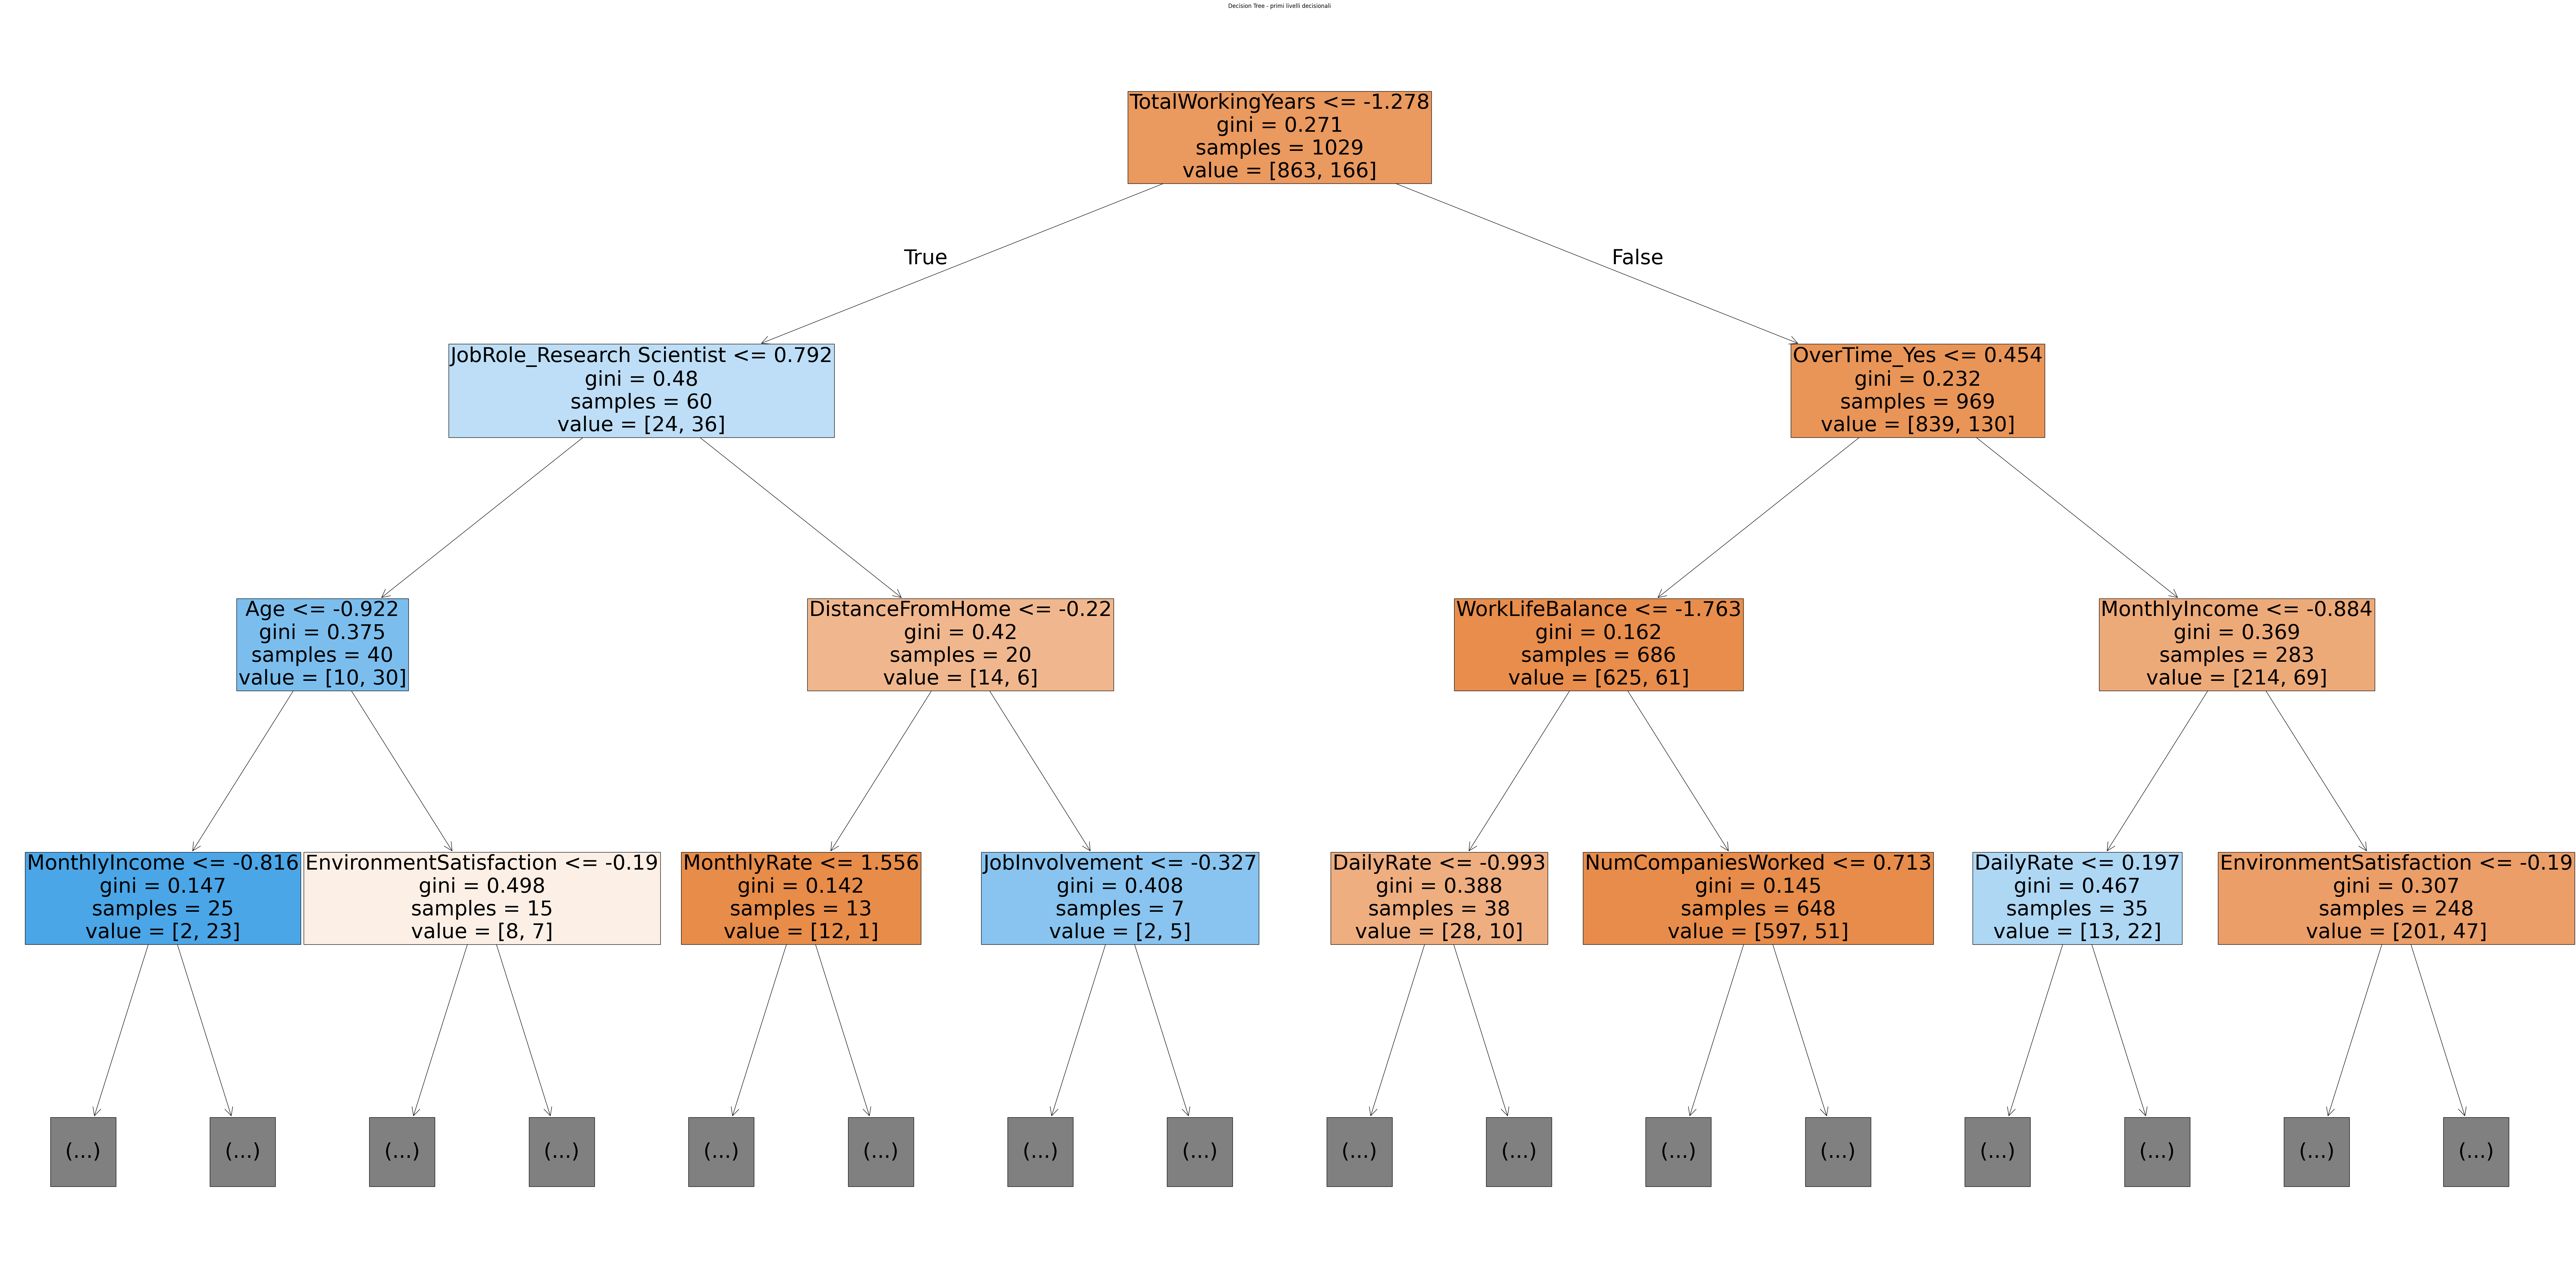

In [234]:
plt.figure(figsize=(100,50))
plot_tree(dt_model,
          filled=True,
          max_depth=3,
          feature_names=X.columns,
          fontsize=45
)
plt.title("Decision Tree - primi livelli decisionali")
plt.show()

---
## Riepilogo Fase 4

1. Il dataset è stato correttamente preparato:
   * rimuovendo le variabili non informative,
   * trasformando quelle categoriche
   * suddividendo i dati in training e test set.

1. La standardizzazione delle feature ha migliorato le prestazioni della regressione logistica e del k-NN.
2. La **regressione logistica** risulta il modello più efficace, con la migliore accuracy e un buon equilibrio generale nelle prestazioni.
3. Il **k-NN** mostra buoni risultati, ma è sensibile alla scelta del parametro k
4. La **Random Forest** offre prestazioni solide e una maggiore capacità di catturare relazioni complesse tra le variabili.
5. Il **Decision Tree** è il modello meno accurato, ma ha il vantaggio di essere facilmente interpretabile e di rendere visibili le regole decisionali.


Tutti i modelli mostrano una difficoltà nel riconoscere correttamente i casi di attrition, suggerendo che la classe “Attrition = Yes” è più complessa da prevedere rispetto a quella dei dipendenti che rimangono.


---
# Fase 5 - Valutazione e interpretazione dei risultati

**Obiettivo:** valutazione critica dei risultati. Per ogni modello calcoliamo
accuracy, confusion matrix, precision, recall e f1-score.


## 5.1 Regressione logistica

Regressione logistica
Accuracy: 0.875



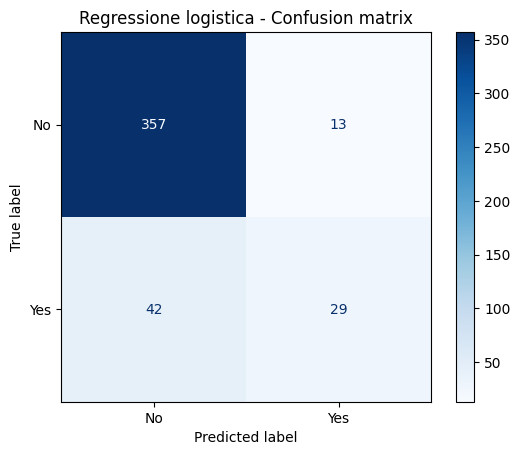

              precision    recall  f1-score   support

          No       0.89      0.96      0.93       370
         Yes       0.69      0.41      0.51        71

    accuracy                           0.88       441
   macro avg       0.79      0.69      0.72       441
weighted avg       0.86      0.88      0.86       441



In [235]:
print("Regressione logistica")
print(f"Accuracy: {acc_log:.3f}\n")

cm_log = confusion_matrix(y_test, pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=["No", "Yes"])
disp.plot(cmap="Blues")
plt.title("Regressione logistica - Confusion matrix")
plt.show()

print(classification_report(y_test, pred_log, target_names=["No", "Yes"]))

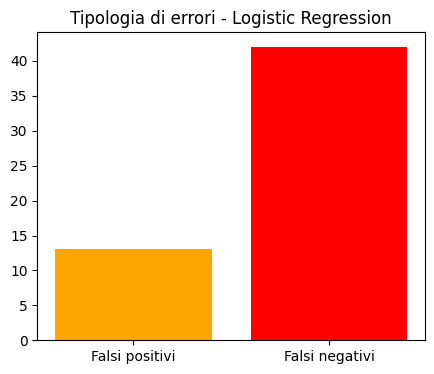

In [236]:
cm = confusion_matrix(y_test, pred_log)

fp = cm[0,1]
fn = cm[1,0]

labels = ["Falsi positivi", "Falsi negativi"]
values = [fp, fn]

plt.figure(figsize=(5,4))
plt.bar(labels, values, color=["orange", "red"])

plt.title("Tipologia di errori - Logistic Regression")
plt.show()

I falsi negativi risultano particolarmente rilevanti, poiché rappresentano dipendenti che lasciano l’azienda ma non vengono identificati dal modello, riducendone l’utilità pratica.

## 5.2 k-NN

k-NN (k=14)
Accuracy: 0.839



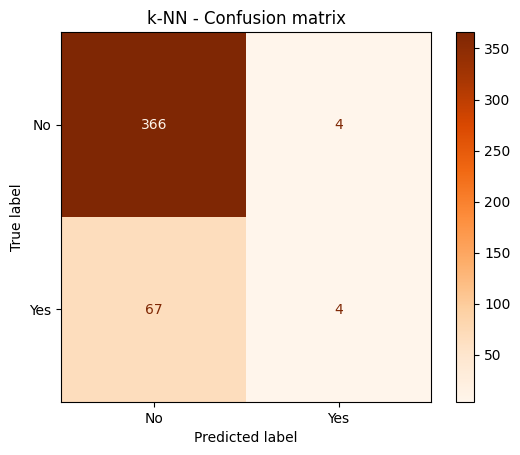

              precision    recall  f1-score   support

          No       0.85      0.99      0.91       370
         Yes       0.50      0.06      0.10        71

    accuracy                           0.84       441
   macro avg       0.67      0.52      0.51       441
weighted avg       0.79      0.84      0.78       441



In [237]:
print("k-NN (k=14)")
print(f"Accuracy: {acc_knn:.3f}\n")

cm_knn = confusion_matrix(y_test, pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=["No", "Yes"])
disp.plot(cmap="Oranges")
plt.title("k-NN - Confusion matrix")
plt.show()

print(classification_report(y_test, pred_knn, target_names=["No", "Yes"]))

## 5.3 Random Forest

Random Forest
Accuracy: 0.832



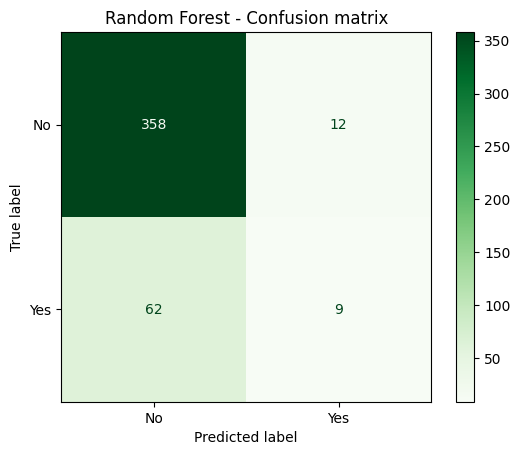

              precision    recall  f1-score   support

          No       0.85      0.97      0.91       370
         Yes       0.43      0.13      0.20        71

    accuracy                           0.83       441
   macro avg       0.64      0.55      0.55       441
weighted avg       0.78      0.83      0.79       441



In [238]:
print("Random Forest")
print(f"Accuracy: {acc_rf:.3f}\n")

cm_rf = confusion_matrix(y_test, pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No", "Yes"])
disp.plot(cmap="Greens")
plt.title("Random Forest - Confusion matrix")
plt.show()

print(classification_report(y_test, pred_rf, target_names=["No", "Yes"]))

### 5.4 Decision Tree

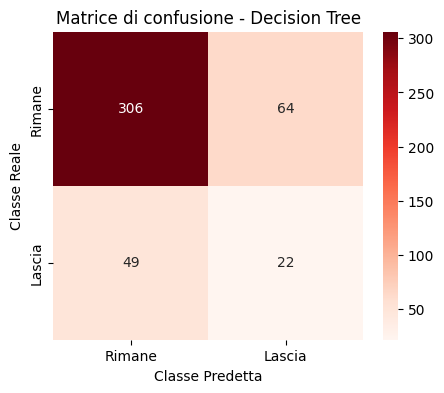

              precision    recall  f1-score   support

      Rimane       0.86      0.83      0.84       370
      Lascia       0.26      0.31      0.28        71

    accuracy                           0.74       441
   macro avg       0.56      0.57      0.56       441
weighted avg       0.76      0.74      0.75       441



In [239]:
cm_dt = confusion_matrix(y_test, pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Reds")

plt.xlabel("Classe Predetta")
plt.ylabel("Classe Reale")

plt.xticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])
plt.yticks(ticks=[0.5, 1.5], labels=["Rimane", "Lascia"])

plt.title("Matrice di confusione - Decision Tree")
plt.show()
print(classification_report(y_test, pred_dt, target_names=["Rimane", "Lascia"]))

## 5.4 Confronto sintetico tra i modelli

Costruiamo una tabella che riassume le metriche principali **per la classe
`Attrition = Yes` (la classe minoritaria, e quella di maggiore interesse
pratico)**.

In [240]:
#tabella di confronto
comparison = pd.DataFrame({
    "Modello": ["Logistic Regression", "k-NN (k=14)", "Random Forest", "Decision Tree"],

    "Accuracy": [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_knn),
        accuracy_score(y_test, pred_rf),
        accuracy_score(y_test, pred_dt)
    ],

    "Recall (Yes)": [
        recall_score(y_test, pred_log),
        recall_score(y_test, pred_knn),
        recall_score(y_test, pred_rf),
        recall_score(y_test, pred_dt)
    ],

    "Precision (Yes)": [
        precision_score(y_test, pred_log),
        precision_score(y_test, pred_knn),
        precision_score(y_test, pred_rf),
        precision_score(y_test, pred_dt)
    ],

    "F1-score (Yes)": [
        f1_score(y_test, pred_log),
        f1_score(y_test, pred_knn),
        f1_score(y_test, pred_rf),
        f1_score(y_test, pred_dt)
    ]
})

comparison = comparison.round(3)
comparison

,Modello,Accuracy,Recall (Yes),Precision (Yes),F1-score (Yes)
0,Logistic Regression,0.875,0.408,0.690,0.513
1,k-NN (k=14),0.839,0.056,0.500,0.101
2,Random Forest,0.832,0.127,0.429,0.196
3,Decision Tree,0.744,0.310,0.256,0.280


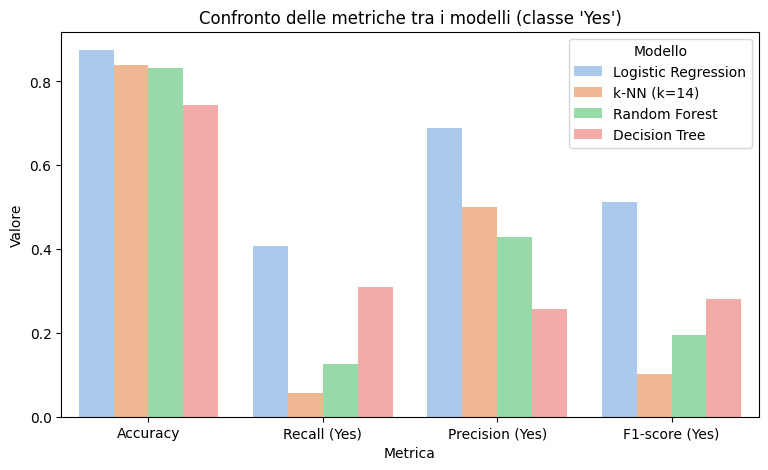

In [241]:
comparison_melted = comparison.melt(
    id_vars="Modello",
    var_name="Metrica",
    value_name="Valore"
)

comparison_melted = comparison_melted[
    comparison_melted["Metrica"] != "Modello"
]

plt.figure(figsize=(9,5))

sns.barplot(
    data=comparison_melted,
    x="Metrica",
    y="Valore",
    hue="Modello",
    palette="pastel"
)

plt.title("Confronto delle metriche tra i modelli (classe 'Yes')")
plt.ylabel("Valore")
plt.xlabel("Metrica")

plt.title("Confronto delle metriche tra i modelli (classe 'Yes')")
plt.show()

**Considerazioni generali:**

- L'**accuracy** è simile e relativamente alta per tutti i modelli, ma è una
  metrica poco informativa qui a causa dello sbilanciamento delle classi: anche
  un modello che predicesse sempre "No" otterrebbe un'accuracy vicina all'84%.
- **Recall** sulla classe "Yes" misura quanti dei dipendenti che effettivamente
  lasciano l'azienda vengono correttamente identificati dal modello: è la
  metrica più rilevante dal punto di vista pratico (un'azienda interessata a
  intervenire preventivamente vuole individuare il maggior numero possibile di
  dipendenti a rischio).
- **Precision** misura quanto sono "affidabili" le previsioni positive del
  modello: precision basse indicano molti falsi allarmi.


## 5.5 Approfondimento - coefficienti della regressione logistica

Osserviamo quali feature hanno il coefficiente più grande (in valore assoluto)
nella regressione logistica: un coefficiente positivo aumenta la probabilità
di `Attrition = Yes`, un coefficiente negativo la diminuisce.

> Ricordiamo che, a causa della multicollinearità individuata in Fase 2
> (Domanda 8), i singoli coefficienti vanno interpretati con cautela: il loro
> valore può essere influenzato dalla presenza di altre variabili correlate.

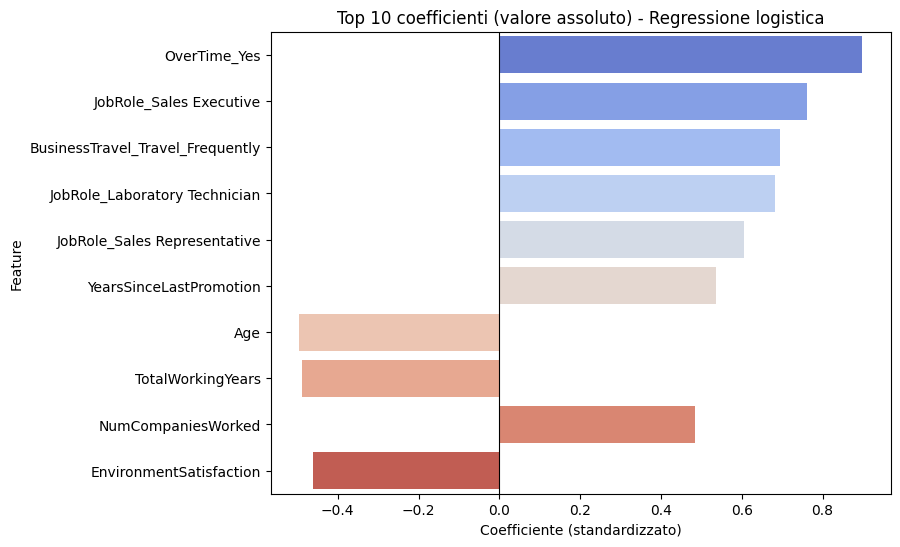

In [242]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficiente": log_model.coef_[0],
})

coef_df["abs_coef"] = coef_df["coefficiente"].abs()
coef_df = coef_df.sort_values("abs_coef", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x="coefficiente", y="feature",
            order=coef_df["feature"],
            hue="feature", palette="coolwarm", legend=False)
plt.title("Top 10 coefficienti (valore assoluto) - Regressione logistica")
plt.xlabel("Coefficiente (standardizzato)")
plt.ylabel("Feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.show()

**Considerazioni:** tra le feature con coefficiente più rilevante troviamo
tipicamente `OverTime_Yes` (coefficiente positivo: fare straordinari aumenta la
probabilità di attrition) e variabili legate all'anzianità/seniority come
`JobLevel` o `TotalWorkingYears` (coefficiente negativo: maggiore anzianità è
associata a minore probabilità di lasciare l'azienda). Questo è coerente con le
osservazioni della Fase 3.

> N.B. c'è un errore nel grafico e nemmeno con l'ausilio dell'AI a correggere la riga NumCompaniesWorked.

## 5.6 Approfondimento - feature importance della Random Forest

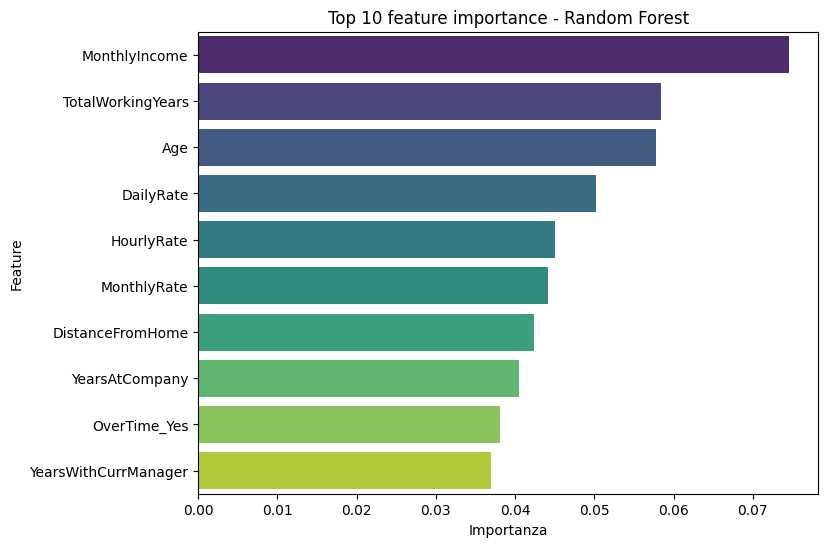

In [243]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False).head(10)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature",
            hue="feature", palette="viridis", legend=False)
plt.title("Top 10 feature importance - Random Forest")
plt.xlabel("Importanza")
plt.ylabel("Feature")
plt.show()

**Considerazioni:** la Random Forest assegna importanza elevata anche a
variabili come `MonthlyIncome`, `Age`, `OverTime_Yes` e alle variabili legate
agli anni di permanenza in azienda. È interessante confrontare questo ranking
con i coefficienti della regressione logistica (5.5): se le due classifiche
sono simili, abbiamo maggiore confidenza che queste variabili siano davvero
rilevanti per il fenomeno, indipendentemente dal modello usato.

## Riepilogo Fase 5 - punti di forza, limiti e costo computazionale

| Modello | Punti di forza | Limiti | Interpretabilità |
|---|---|---|---|
| Regressione logistica | semplice, rapida, coefficienti interpretabili | assume relazioni (approssimativamente) lineari tra feature e log-odds | alta (coefficienti) |
| k-NN | nessuna fase di training "vera e propria", intuitivo | sensibile alla scala delle feature e alla dimensionalità, lento in previsione su dataset grandi | bassa |
| Random Forest | gestisce bene relazioni non lineari e interazioni, robusta | meno interpretabile di un modello lineare, rischio di overfitting se non regolata | media (feature importance) |
| Decision Tree | rende visibili le decisioni prese dal modello | meno accuratteza | molto alta

**Tipo di errori:** osservando le confusion matrix, tutti i modelli tendono a
generare più falsi negativi (dipendenti che lasciano l'azienda ma vengono
predetti come "rimangono") che falsi positivi, coerentemente con lo
sbilanciamento del dataset verso la classe "No". In un contesto reale, questo
tipo di errore è particolarmente costoso, perché significa non intervenire su
dipendenti effettivamente a rischio.


---
# Fase 5 bis - Approfondimenti

> **N.B. questi approfondimenti sono stati svolti con l'utilizzo dell'AI, in quanto mancanze di conoscenze teoriche e pratiche in materia**

Le metriche calcolate finora (accuracy, precision, recall, f1-score) sono
tutte basate su un'unica soglia di decisione (0.5) e su un'unica suddivisione
train/test. In questa sezione approfondiamo l'analisi con tre strumenti
complementari:

1. **Curva ROC e AUC**: valutano la capacità dei modelli di ordinare le
   osservazioni per probabilità predetta, indipendentemente dalla soglia.
2. **Curva precision-recall al variare della soglia**: mostrano come cambia
   il compromesso precision/recall scegliendo soglie diverse da 0.5.

## 5.7 Curva ROC e AUC

La curva ROC (*Receiver Operating Characteristic*) mette in relazione, al
variare della soglia di decisione, il **tasso di veri positivi** (recall sulla
classe "Yes") e il **tasso di falsi positivi** (quota di "No" classificati
erroneamente come "Yes").

L'**AUC** (*Area Under the Curve*) sintetizza la curva in un singolo numero tra
0.5 (modello non migliore di una scelta casuale) e 1 (modello perfetto):
misura quanto bene il modello, in generale, assegna probabilità più alte ai
casi positivi rispetto ai negativi, **senza dipendere da una soglia
specifica**. Per questo è una metrica particolarmente indicata quando le
classi sono sbilanciate, come nel nostro caso.

Per calcolarla servono le **probabilità predette** (non le classi), tramite
`predict_proba`.

In [244]:
from sklearn.metrics import roc_curve, roc_auc_score

# probabilità predette per la classe "Yes" (1) sul test set
proba_log = log_model.predict_proba(X_test_scaled)[:, 1]
proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

auc_log = roc_auc_score(y_test, proba_log)
auc_knn = roc_auc_score(y_test, proba_knn)
auc_rf = roc_auc_score(y_test, proba_rf)

print(f"AUC regressione logistica: {auc_log:.3f}")
print(f"AUC k-NN: {auc_knn:.3f}")
print(f"AUC Random Forest: {auc_rf:.3f}")

AUC regressione logistica: 0.823
AUC k-NN: 0.714
AUC Random Forest: 0.767


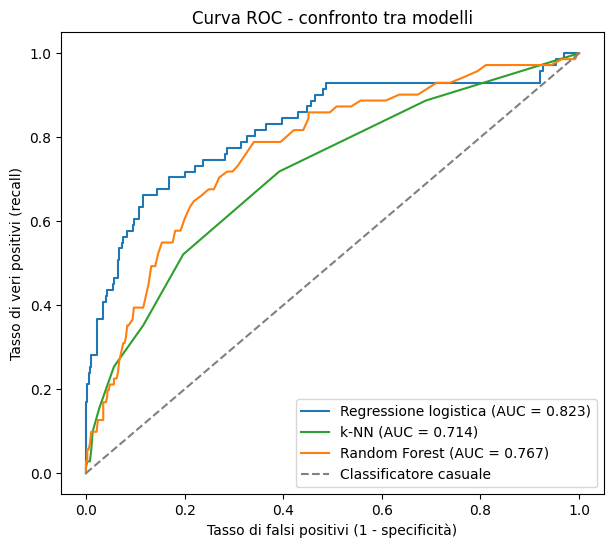

In [245]:
plt.figure(figsize=(7, 6))

for proba, auc, label, color in [
    (proba_log, auc_log, "Regressione logistica", "tab:blue"),
    (proba_knn, auc_knn, "k-NN", "tab:green"),
    (proba_rf, auc_rf, "Random Forest", "tab:orange"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})", color=color)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Classificatore casuale")
plt.xlabel("Tasso di falsi positivi (1 - specificità)")
plt.ylabel("Tasso di veri positivi (recall)")
plt.title("Curva ROC - confronto tra modelli")
plt.legend()
plt.show()

**Considerazioni:** l'AUC permette un confronto tra modelli "a parità di
soglia ideale", utile quando non abbiamo ancora deciso quale soglia usare in
pratica. Tipicamente la regressione logistica ottiene l'AUC più alta su questo
dataset, il che indica che ordina meglio i dipendenti per rischio di attrition
rispetto a k-NN e Random Forest, anche se l'accuracy con soglia 0.5 (Fase 5)
era simile tra i modelli. Questo conferma che **accuracy e AUC misurano
aspetti diversi** della qualità di un modello: l'AUC è più informativa qui,
proprio perché il dataset è sbilanciato.

## 5.8 Variazione della soglia di decisione

Finora abbiamo sempre usato la soglia standard 0.5 per trasformare una
probabilità in una classe (`probabilità ≥ 0.5 → Attrition = Yes`). Come visto
nel notebook sulla regressione logistica, **cambiare soglia cambia le
decisioni**: una soglia più bassa rende il modello più "sensibile" (recall più
alta, ma più falsi positivi), una soglia più alta lo rende più "prudente"
(precision più alta, ma più falsi negativi).

Analizziamo questo compromesso per il modello con l'AUC più alta (la
regressione logistica) usando la curva precision-recall.

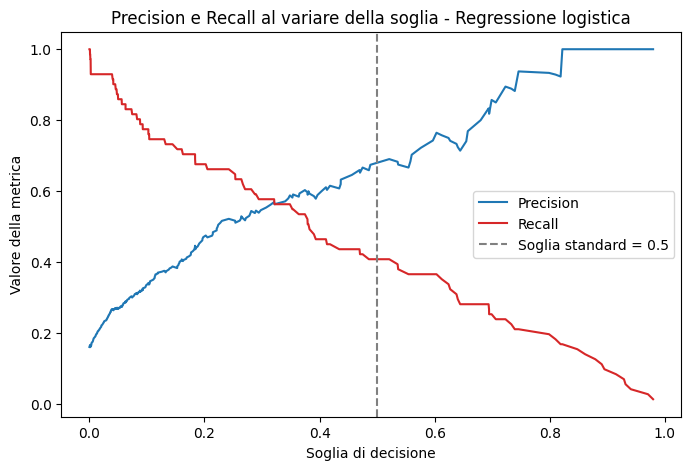

In [246]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, proba_log)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="tab:blue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="tab:red")
plt.axvline(0.5, linestyle="--", color="gray", label="Soglia standard = 0.5")
plt.xlabel("Soglia di decisione")
plt.ylabel("Valore della metrica")
plt.title("Precision e Recall al variare della soglia - Regressione logistica")
plt.legend()
plt.show()

In [247]:
# Confronto puntuale tra alcune soglie scelte
selected_thresholds = [0.2, 0.3, 0.4, 0.5, 0.7]

threshold_results = []
for t in selected_thresholds:
    pred_t = (proba_log >= t).astype(int)
    threshold_results.append({
        "soglia": t,
        "precision_yes": precision_score(y_test, pred_t, zero_division=0),
        "recall_yes": recall_score(y_test, pred_t, zero_division=0),
        "f1_yes": f1_score(y_test, pred_t, zero_division=0),
    })

pd.DataFrame(threshold_results).round(3)

,soglia,precision_yes,recall_yes,f1_yes
0,0.2,0.475,0.676,0.558
1,0.3,0.554,0.577,0.566
2,0.4,0.600,0.465,0.524
3,0.5,0.690,0.408,0.513
4,0.7,0.850,0.239,0.374


**Considerazioni:** abbassando la soglia (es. a 0.2-0.3) la recall sulla
classe "Yes" aumenta sensibilmente rispetto alla soglia 0.5, a costo di una
precision più bassa (più falsi positivi). Alzando la soglia (es. a 0.7) accade
l'opposto. La scelta della soglia "migliore" non è quindi puramente tecnica, ma
dipende dal contesto applicativo: se l'obiettivo è individuare il maggior
numero possibile di dipendenti a rischio (anche a costo di qualche falso
allarme), una soglia più bassa di 0.5 può essere preferibile.

---
# Conclusioni

## Conclusioni principali

- `OverTime`, `MonthlyIncome`, `Age` e le variabili legate all'anzianità
  (`JobLevel`, `TotalWorkingYears`, `YearsAtCompany`, ecc.) emergono come i
  fattori più associati all'attrition, sia nell'analisi esplorativa (Fase 3)
  sia nei modelli (Fase 5).
- Il dataset è sbilanciato: l'accuracy da sola non è una metrica adeguata, ed è
  preferibile guardare precision/recall/f1 sulla classe minoritaria
  (`Attrition = Yes`).
- I tre modelli ottengono performance comparabili in termini di accuracy, ma si
  differenziano per recall, interpretabilità e costo computazionale: la scelta
  del modello "migliore" dipende dall'obiettivo concreto (es. massimizzare la
  recall per individuare il maggior numero di dipendenti a rischio, oppure
  privilegiare l'interpretabilità per spiegare le decisioni al management).
- Gli approfondimenti di Fase 5 bis confermano e rafforzano queste conclusioni:
  la regressione logistica ottiene l'AUC più alto, sia con un singolo
  train/test split sia in cross-validation, indicando che è il modello che
  ordina meglio i dipendenti per rischio di attrition. La curva
  precision-recall mostra inoltre che, abbassando la soglia di decisione sotto
  0.5, è possibile aumentare sensibilmente la recall sulla classe "Yes" a
  fronte di una precision più bassa: una scelta che potrebbe avere senso in un
  contesto in cui mancare un dipendente a rischio è più costoso di un falso
  allarme.